# Random Forest
--> Combination of multiple trees together is known as random forest.<br>
--> It is one of the bagging technique. It has multiple trees so it is called as bagging technique<br>
--> In ensemble learning we have two types bagging and boosting <br>
<br>
1. Limitations of decision tree<br>
2. Intro to ensemble learning<br>
3. Types of ensemle learning<br>
4. Bagging -> Randforest<br>
5. Boosting -> AdaBoost,Gradient Boost,XEBoost<br>
6. What is stacking<br>


1. Limitations of Decision Tree<br>
-- Overfitting<br>


--> In randf we connect the multiple trees parallely<br>
--> Majority output of all the decision trees output is the output of the randomforest model for classification<br>
--> Average output of all the decision trees output is the output of the randomforest model for regression<br>
-->Classification - Majority Voting classifier<br>
--> Regression -Average output of the models<br>
--> Decision Tree<br>
 - Low bias,High variance,High Overfitting<br>
 --> Randf<br>
<br>
 - Low bias,Low variance,Low Overfitting<br>
 <br>
--> Bagging - It is an ensemble technique that combines multiple models trained in parallel.<br>
--> Boosting - Boosting is an ensemble technique where models are trained sequentially.<br>
--> Weak learner - Have'nt learned much from Training data (Boosting)<br>
--> Strong Learner - learned much from Training data (Bagging)<br>
--> AdaBoost - Assigns weights to the weak learners. Formula : f=alpha1(m1)+alpha2(m2)+alpha3(m3)+....alpha'n'(m'n')<br>
<br>
--> Applying all algorithms(linear reg,log reg,deccisio tree,randforest, etcc) to the dataset is known as stacking<br>
--> Stacking helps to find the best model for the dataset which gives high accuracy<br>




In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.shape

(1025, 14)

In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

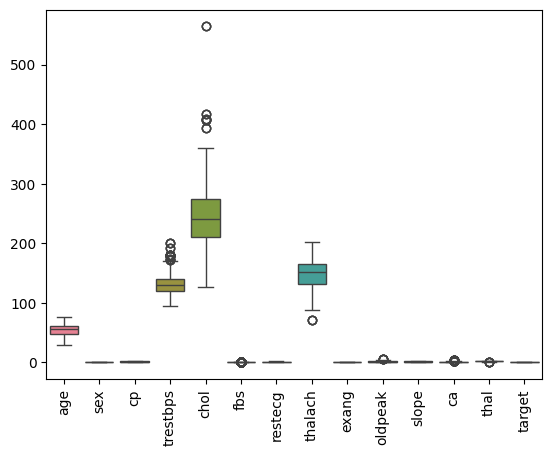

In [8]:
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [9]:
columns = ['trestbps', 'chol', 'oldpeak', 'fbs', 'ca','thalach','cp']

for col in columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

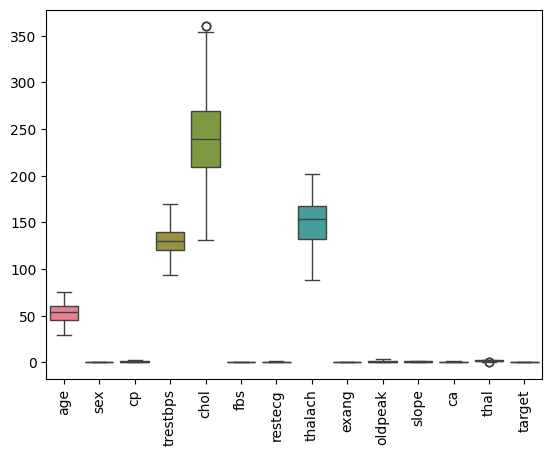

In [10]:
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

In [11]:
X = df[['age','cp','thalach','oldpeak','ca','thal','exang','slope']]
y = df['target']

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
y_pred=model.predict(X_test)
print(y_pred)

[1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 0 1 0 0 0 0
 1 0 0 0 0 1 1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 0
 1 1 0 1 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 1 1
 1 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0
 0 1 1 0 1 0 0]


In [15]:
from sklearn.metrics import accuracy_score
accu=accuracy_score(y_pred,y_test)
print(accu)

1.0


In [16]:
params={
    'n_estimators': [100, 200],
    'criterion':['gini'], 
    'max_depth':[5],
    'min_samples_split':[2], 
    'min_samples_leaf':[1]
}

In [17]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

In [18]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini'], 'max_depth': [5], 'min_samples_leaf': [1], 'min_samples_split': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [19]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [20]:
y_pred=grid.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score
accu=accuracy_score(y_pred,y_test)
print(accu)

0.9225806451612903


In [22]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_pred,y_test)
print("Confusion Matrix: ",cm)

Confusion Matrix:  [[63  3]
 [ 9 80]]


In [23]:
from sklearn.metrics import classification_report
cr=classification_report(y_pred,y_test)
print("Classification Report: ",cr)

Classification Report:                precision    recall  f1-score   support

           0       0.88      0.95      0.91        66
           1       0.96      0.90      0.93        89

    accuracy                           0.92       155
   macro avg       0.92      0.93      0.92       155
weighted avg       0.93      0.92      0.92       155



In [27]:
import pickle
with open("ranf.pkl","wb") as f:
    pickle.dump(model,f)
